In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
import os
sys.path.append(os.path.abspath(".."))
import utils.plot_utils as pu

In [23]:
# loading dataset and standadizing it
iris = datasets.load_iris()
print(type(iris))

# both x and y are numpy ndarrays
X = iris.data[:,[2,3]]
y = iris.target

# Stratify parameter= divides the training and testing data having the same proportion for each 
# label as the original dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# verification of the stratify split
# print("Labels in y : ", np.bincount(y))
# print("Labels in y_train : ", np.bincount(y_train))
# print("Labels in y_test : ", np.bincount(y_test))

sc = StandardScaler()
sc.fit(X_train)

X_std = sc.transform(X)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

<class 'sklearn.utils._bunch.Bunch'>


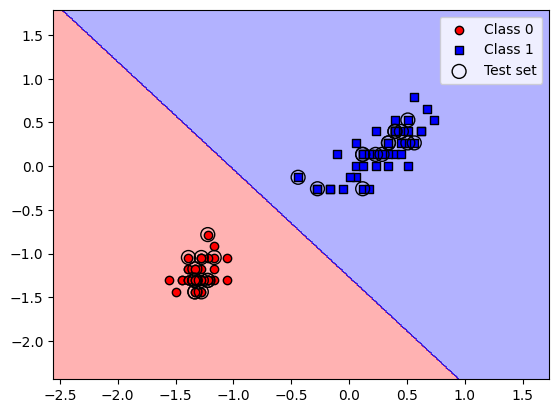

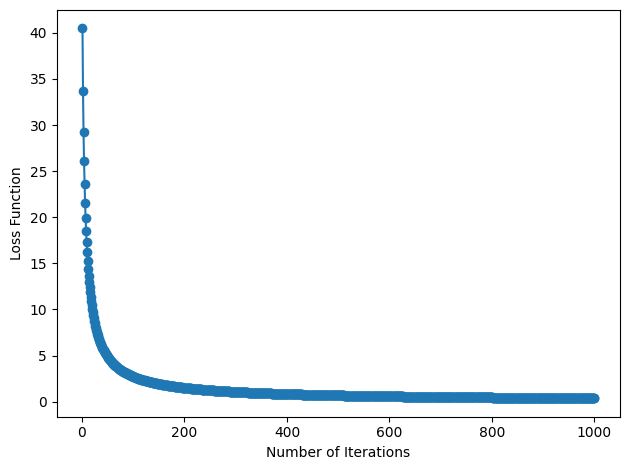

In [24]:
# Manually created Logistic Regression Model 
# hyperparameters - eta, n_iter
# X - (examples, features)
# y - (examples,)
# w - (features,)

class LogisticRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.b_ = 0.0
        self.loss_ = []

        rgen = np.random.default_rng(self.random_state)
        self.w_ = rgen.normal(loc=0, scale=0.3, size=X.shape[1])

        for i in range(self.n_iter):
            z = self.net_input(X)
            output = self.activation(z)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()

            log_loss = (-y.dot(np.log(output))) - ((1-y).dot(np.log(1-output)))
            self.loss_.append(log_loss)

    def net_input(self, X):
        # calculate and return net input
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        # return the sigmoid function
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):    
        # predict class label
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0) 

# fitting model on the data
X_train_01 = X_train_std[(y_train==0) | (y_train==1)]
y_train_01 = y_train[(y_train==0) | (y_train==1)]

lg = LogisticRegressionGD(eta=0.3, n_iter=1000, random_state=1)
lg.fit(X_train_01, y_train_01)

pu.plot_decision_regions(X=X_std[(y==0) | (y==1)], y=y[(y==0) | (y==1)], 
model=lg, X_test=X_test_std[(y_test==0) | (y_test==1)], resolution=0.01)
plt.show()

pu.plot_loss(lg.n_iter, lg.loss_)
plt.show()


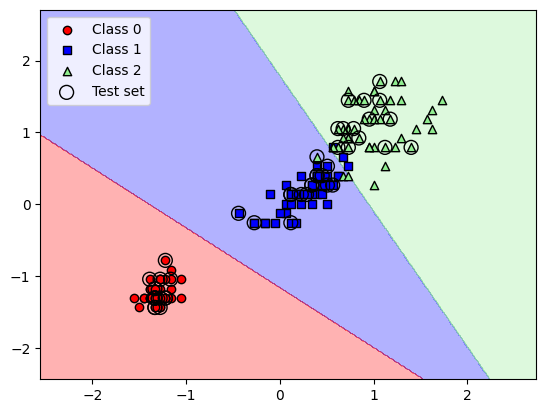

[[9.37368464e-13 3.91458193e-04 9.99608542e-01]
 [9.93631074e-01 6.36892585e-03 1.20730798e-15]
 [9.98707332e-01 1.29266792e-03 1.82177043e-17]]
[2 0 0]


In [25]:
# Scikit-learn logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0, solver='lbfgs')
lr.fit(X_train_std, y_train)

pu.plot_decision_regions(X=X_std, y=y, model=lr, X_test=X_test_std)
plt.show()

# sklearn always expect two-dimensional array as input
print(lr.predict_proba(X_test_std[:3, :]))
print(lr.predict(X_test_std[:3, :])) 